TASK-2

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Exploratory Data Analysis on Iris Dataset

## Introduction

This project performs Exploratory Data Analysis (EDA) on the Iris dataset.

The objective is to understand the structure of the dataset, analyze distributions and relationships between variables, identify potential outliers, and extract meaningful insights using statistical analysis and visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

%matplotlib inline

sns.set_theme(style="whitegrid")

In [4]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [6]:
df.shape

(150, 5)

In [7]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


In [10]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


DATA CLEANING

In [13]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
142,5.8,2.7,5.1,1.9,virginica


Summary statistics

In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [17]:
df.groupby("species").describe()

sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

### Observation

The summary statistics provide information about the central tendency and spread of the numerical features. The measurements vary across the three Iris species, particularly for petal length and petal width.

Correlation heatmap

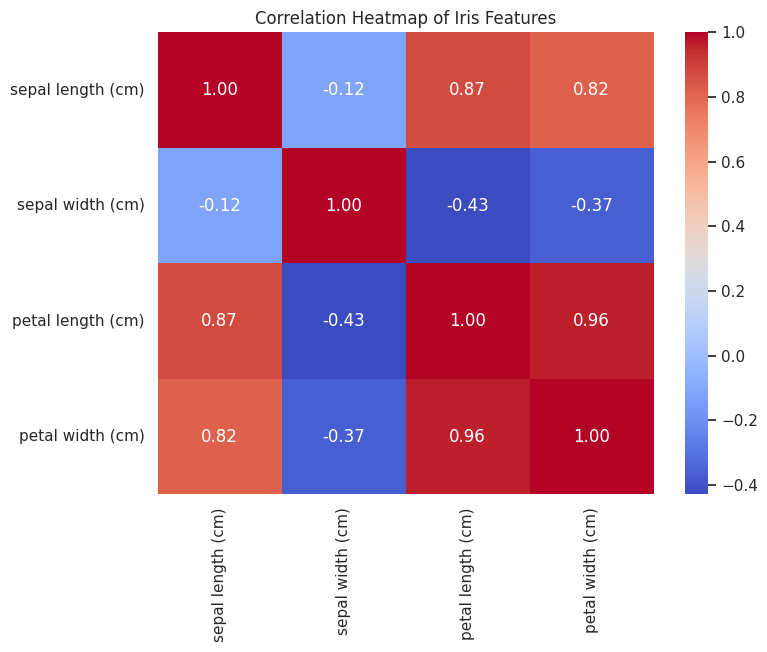

In [18]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Iris Features")
plt.show()

### Observation

The correlation heatmap shows the relationships between the numerical features. Petal length and petal width show a strong positive relationship, while some other feature pairs have weaker relationships.

Visualization 1: Species Distribution

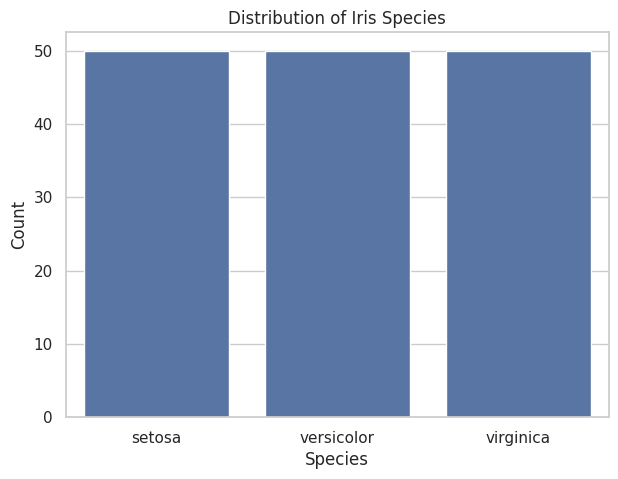

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains three Iris species: Setosa, Versicolor, and Virginica. Each species has an equal number of observations, making the dataset balanced with respect to the target species.

Visualization 2: Sepal Length Distribution

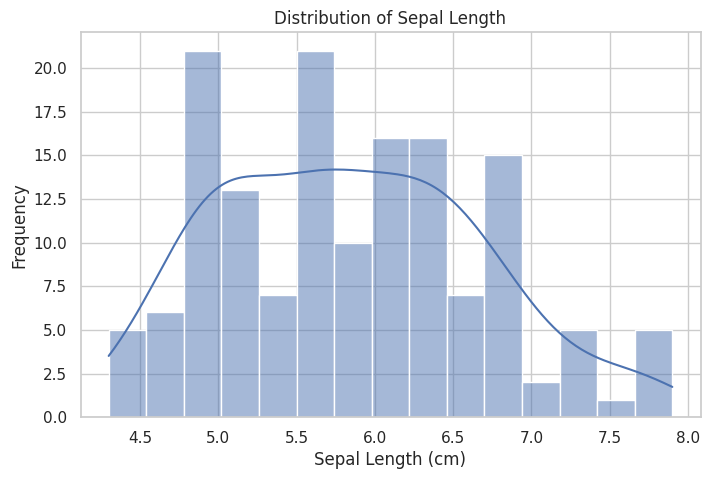

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sepal length (cm)",
    bins=15,
    kde=True
)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of sepal length values. Most observations fall within a moderate range, with fewer observations occurring at the extreme values.

Visualization 3: Boxplot for Outliers

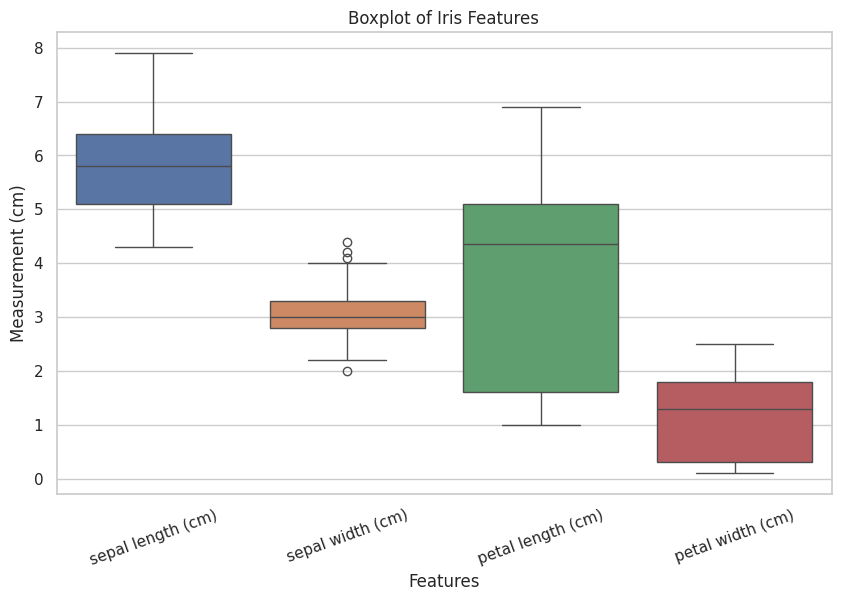

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numeric_df.columns])

plt.title("Boxplot of Iris Features")
plt.xlabel("Features")
plt.ylabel("Measurement (cm)")

plt.xticks(rotation=20)

plt.show()

### Observation

The boxplots show the spread of the four numerical features and highlight potential observations outside the typical range. These observations should be investigated further before deciding whether they are genuine values or data errors.

Visualization 4: Petal Length by Species

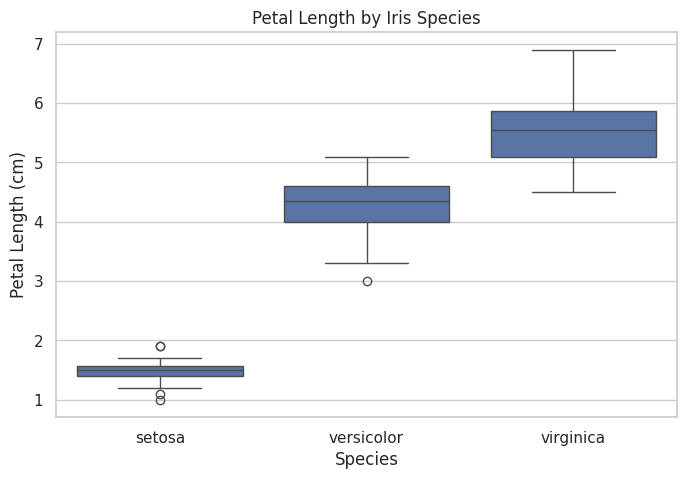

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)"
)

plt.title("Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.show()

### Observation

Petal length differs considerably among the three Iris species. Setosa generally has smaller petal lengths, while Virginica has larger petal lengths. Versicolor generally falls between the other two species.

Visualization 5: Petal Width by Species

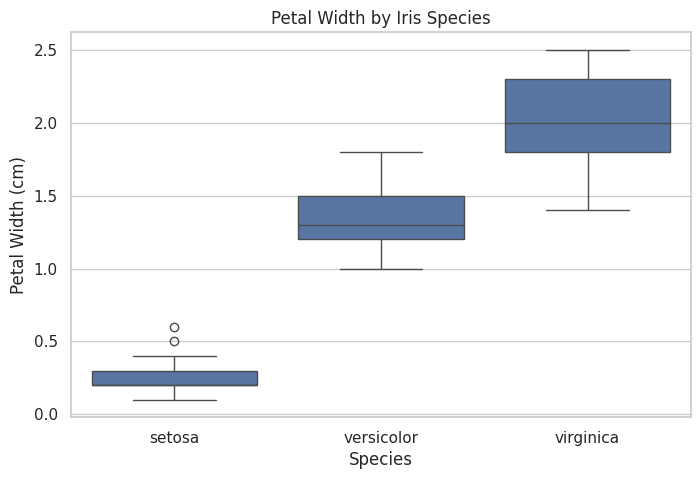

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="species",
    y="petal width (cm)"
)

plt.title("Petal Width by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Width (cm)")

plt.show()

### Observation

Petal width shows clear differences among the three species. Setosa generally has the smallest petal width, while Virginica generally has the largest. This feature appears useful for distinguishing the species.

Visualization 6: Scatter Plot

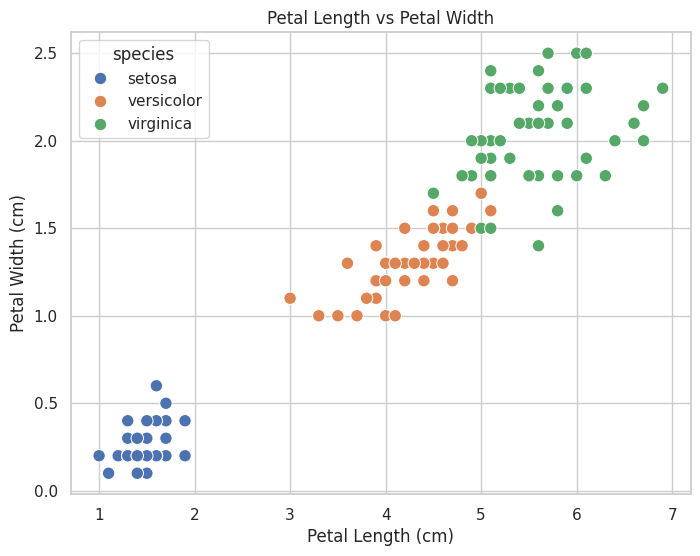

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

### Observation

The scatter plot shows a strong positive relationship between petal length and petal width. The species form relatively distinct groups, indicating that these two features are useful for differentiating the Iris species.

Visualization 7: Pairplot

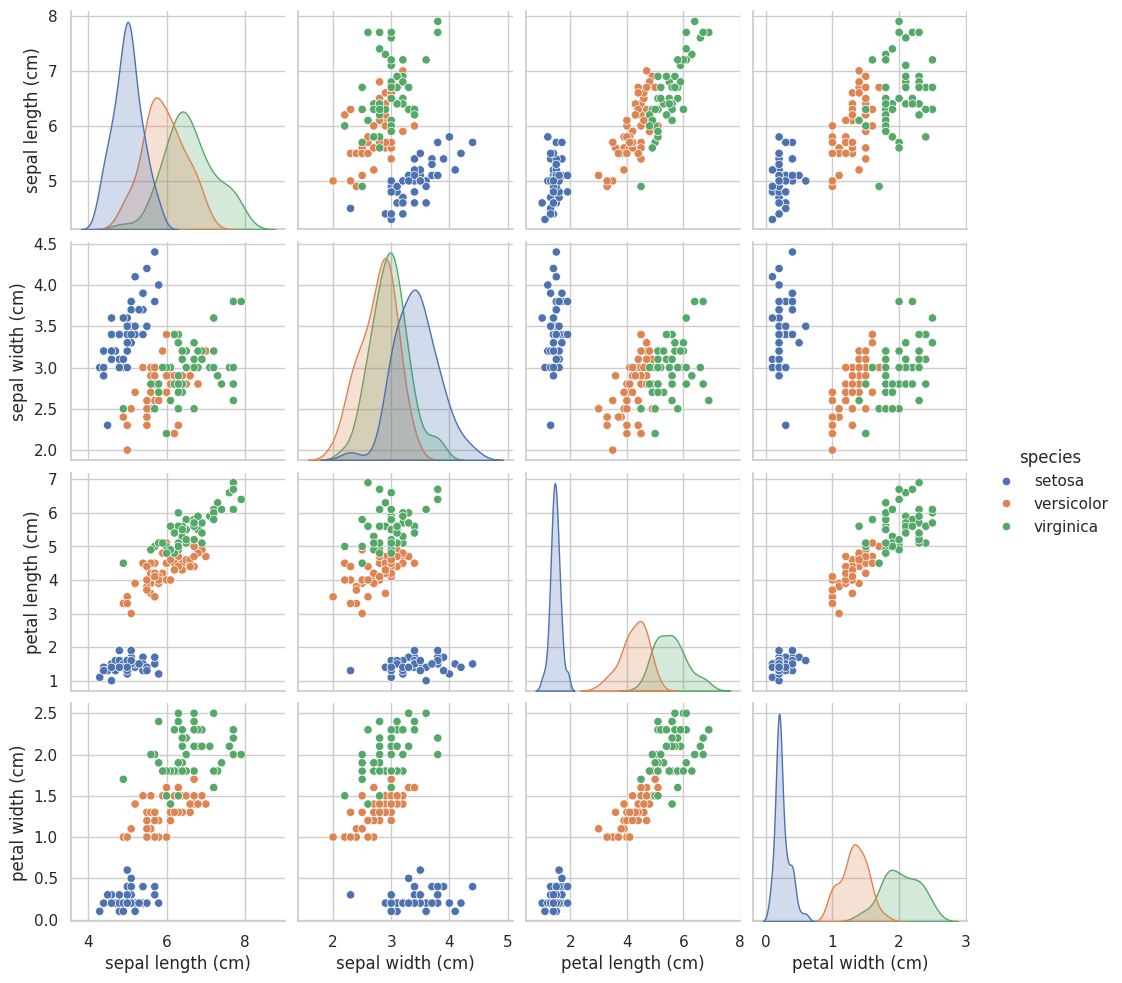

In [25]:
sns.pairplot(
    df,
    hue="species"
)

plt.show()

### Observation

The pairplot provides an overall view of the relationships between the numerical features. Petal-related features show clearer separation between species compared with the sepal-related features.